<a href="https://colab.research.google.com/github/adityaranjan11/E-commerece-promo-roi-analysis/blob/main/Campaign_ROI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

num_rows = 5000
start_date = datetime(2026, 1, 1)

# Generate baseline vectors
invoice_nos = [f"INV{random.randint(100000, 999999)}" for _ in range(num_rows)]
stock_codes = [f"PROD{random.randint(10, 99)}" for _ in range(num_rows)]
quantities = np.random.choice([1, 2, 3, 4, 5, 10, -1, -2], size=num_rows, p=[0.4, 0.3, 0.1, 0.05, 0.05, 0.05, 0.03, 0.02])
unit_prices = np.random.uniform(5.0, 150.0, size=num_rows).round(2)
customer_ids = [float(random.randint(14000, 14500)) for _ in range(num_rows)]
dates = [start_date + timedelta(days=random.randint(0, 90), hours=random.randint(0, 23)) for _ in range(num_rows)]

# Introduce discount codes (Campaign ran in February 2026)
discount_codes = []
for dt in dates:
    if dt.month == 2:  # February Promo Campaign
        discount_codes.append(random.choice(['PROMO20', 'BOGO', 'PROMO20', None, None]))
    else:
        discount_codes.append(random.choice([None, 'WELCOME10', None]))

df = pd.DataFrame({
    'InvoiceNo': invoice_nos,
    'StockCode': stock_codes,
    'Quantity': quantities,
    'InvoiceDate': dates,
    'UnitPrice': unit_prices,
    'CustomerID': customer_ids,
    'DiscountCode': discount_codes
})

# Ingest Messiness
# 1. Duplicate rows
df = pd.concat([df, df.sample(n=150)], ignore_index=True)
# 2. Missing Customer IDs (Simulating guest checkouts)
df.loc[df.sample(frac=0.08).index, 'CustomerID'] = np.nan
# 3. String inconsistencies in Discount Codes
df['DiscountCode'] = df['DiscountCode'].apply(lambda x: x.lower() if (x and random.random() > 0.5) else x)

df.to_csv('raw_ecommerce_data.csv', index=False)
print("Successfully generated 'raw_ecommerce_data.csv' with 5,150 rows!")

Successfully generated 'raw_ecommerce_data.csv' with 5,150 rows!


In [2]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv('raw_ecommerce_data.csv')
print(f"Initial row count: {len(df)}")

# 2. Remove Exact Duplicates
df.drop_duplicates(inplace=True)

# 3. Standardize Strings (Discount Codes)
df['DiscountCode'] = df['DiscountCode'].str.upper().str.strip()
df['DiscountCode'] = df['DiscountCode'].replace({np.nan: 'NONE'})

# 4. Handle Missing Customer IDs
df['CustomerID'] = df['CustomerID'].fillna(-1).astype(int).astype(str)
df['CustomerID'] = df['CustomerID'].replace('-1', 'GUEST')

# 5. Filter for Successful Sales (Drop returns for this analysis layer)
df_sales = df[df['Quantity'] > 0].copy()

# 6. Calculate Financial Columns
discount_map = {'PROMO20': 0.20, 'BOGO': 0.50, 'WELCOME10': 0.10, 'NONE': 0.00}
df_sales['DiscountPct'] = df_sales['DiscountCode'].map(discount_map)

df_sales['GrossRevenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales['DiscountAmount'] = df_sales['GrossRevenue'] * df_sales['DiscountPct']
df_sales['NetRevenue'] = df_sales['GrossRevenue'] - df_sales['DiscountAmount']

# 7. Export Cleared Sales Data
df_sales.to_csv('clean_ecommerce_sales.csv', index=False)
print(f"Cleaned data exported! Final sales rows: {len(df_sales)}")

Initial row count: 5150
Cleaned data exported! Final sales rows: 4780


In [3]:
# Install duckdb and its notebook extension
!pip install duckdb duckdb-engine --quiet

import duckdb
# Connect to a local in-memory database
con = duckdb.connect()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.9 MB/s eta 0:00:00


In [4]:
# Create a SQL table directly from our clean CSV file
con.execute("CREATE TABLE sales AS SELECT * FROM read_csv_auto('clean_ecommerce_sales.csv');")

# Query the database using SQL and display it as a clean table
df_view = con.execute("SELECT * FROM sales LIMIT 5;").df()
df_view

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,DiscountCode,DiscountPct,GrossRevenue,DiscountAmount,NetRevenue
0,INV770487,PROD32,1,2026-01-04 07:00:00,62.08,14129,NONE,0.0,62.08,0.00,62.08
1,INV126225,PROD40,3,2026-03-11 03:00:00,128.91,14196,NONE,0.0,386.73,0.00,386.73
2,INV877572,PROD85,2,2026-01-09 06:00:00,54.30,14158,WELCOME10,0.1,108.60,10.86,97.74
3,INV388389,PROD50,1,2026-03-18 00:00:00,131.10,14327,NONE,0.0,131.10,0.00,131.10
4,INV356787,PROD99,1,2026-02-09 06:00:00,17.78,14490,NONE,0.0,17.78,0.00,17.78


In [5]:
# Run the SQL Monthly Performance Query
query_1 = """
SELECT
    EXTRACT(MONTH FROM CAST(InvoiceDate AS TIMESTAMP)) AS sales_month,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    COUNT(DISTINCT CustomerID) AS unique_customers,
    ROUND(SUM(GrossRevenue), 2) AS gross_rev,
    ROUND(SUM(DiscountAmount), 2) AS total_discounts_given,
    ROUND(SUM(NetRevenue), 2) AS net_rev,
    ROUND(SUM(NetRevenue) / COUNT(DISTINCT InvoiceNo), 2) AS AOV
FROM sales
GROUP BY 1
ORDER BY 1;
"""

# Execute and view the output dataframe
performance_df = con.execute(query_1).df()
performance_df

,sales_month,total_orders,unique_customers,gross_rev,total_discounts_given,net_rev,AOV
0,1,1631,475,293660.07,9599.97,284060.10,174.16
1,2,1473,470,261806.51,50776.52,211030.00,143.27
2,3,1594,469,292197.54,9773.01,282424.53,177.18
3,4,42,40,6977.78,158.67,6819.11,162.36


In [6]:
# Run the Promo Code Performance Query
query_2 = """
SELECT
    DiscountCode,
    COUNT(DISTINCT InvoiceNo) AS usage_count,
    ROUND(SUM(GrossRevenue), 2) AS gross_sales_generated,
    ROUND(SUM(DiscountAmount), 2) AS dollar_value_lost,
    ROUND(SUM(NetRevenue), 2) AS net_sales_retained,
    ROUND((SUM(DiscountAmount) / SUM(GrossRevenue)) * 100, 2) AS effective_discount_rate
FROM sales
GROUP BY 1
ORDER BY net_sales_retained DESC;
"""

promo_df = con.execute(query_2).df()
promo_df

,DiscountCode,usage_count,gross_sales_generated,dollar_value_lost,net_sales_retained,effective_discount_rate
0,NONE,2771,499879.81,0.00,499879.81,0.0
1,WELCOME10,1078,195316.47,19531.65,175784.82,10.0
2,PROMO20,587,96487.65,19297.53,77190.12,20.0
3,BOGO,303,62957.97,31478.98,31478.98,50.0


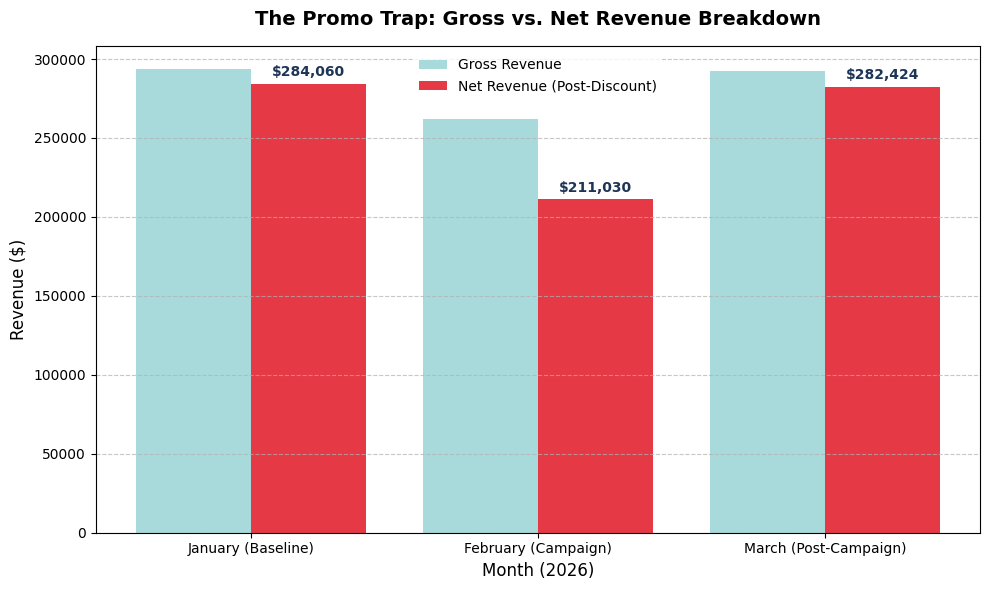

In [7]:
import matplotlib.pyplot as plt

# Filter down to the full months (1, 2, 3) since month 4 is just starting data
plot_data = performance_df[performance_df['sales_month'].isin([1, 2, 3])]

plt.figure(figsize=(10, 6))

# Plot Gross Revenue
plt.bar(plot_data['sales_month'] - 0.2, plot_data['gross_rev'], width=0.4, label='Gross Revenue', color='#a8dadc')
# Plot Net Revenue
plt.bar(plot_data['sales_month'] + 0.2, plot_data['net_rev'], width=0.4, label='Net Revenue (Post-Discount)', color='#e63946')

plt.title('The Promo Trap: Gross vs. Net Revenue Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month (2026)', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks([1, 2, 3], ['January (Baseline)', 'February (Campaign)', 'March (Post-Campaign)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True, facecolor='white', edgecolor='none')

# Add values on top of the Net Revenue bars
for index, row in plot_data.iterrows():
    plt.text(row['sales_month'] + 0.2, row['net_rev'] + 5000, f"${int(row['net_rev']):,}", ha='center', fontweight='bold', color='#1d3557')

plt.tight_layout()
plt.show()